In [ ]:
import pandas as pd
import ast
import io
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

import torch
import torch.nn as nn
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import plotly.express as px
import umap

In [ ]:
# Step 1: Manual File Selection
print("Please upload your 'mtg_final_classified_deck.csv' file:")
uploaded = files.upload()

# Step 2: Read the file
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Step 3: Handle the [] empty data as requested
def mark_empty_data(tag_str):
    """
    Converts stringified lists to actual lists.
    Replaces empty lists [] with a specific marker for the Self-Attention layer.
    """
    try:
        # Check if it's a string representation of a list
        if isinstance(tag_str, str):
            tags = ast.literal_eval(tag_str)
        else:
            tags = tag_str

        # If it's a list but empty, or if it's NaN
        if not tags or (isinstance(tags, list) and len(tags) == 0):
            return ["EMPTY_DATA"]
        return tags
    except (ValueError, SyntaxError):
        # Handle cases where data might be missing or malformed
        return ["EMPTY_DATA"]

# Apply the marker to your key columns
df['manual_tags'] = df['manual_tags'].apply(mark_empty_data)
df['generated_effect_tags'] = df['generated_effect_tags'].apply(mark_empty_data)

# Print a quick check for cards like Wound Reflection
print("\nSample Check (Empty Data Handling):")
print(df[['name', 'generated_effect_tags']].tail())

Please upload your 'mtg_final_classified_deck.csv' file:


Saving mtg_final_classified_deck.csv to mtg_final_classified_deck.csv

Sample Check (Empty Data Handling):
                            name                  generated_effect_tags
10022     White Plume Adventurer        [Dungeon Delver, Upkeep Master]
10023            Witch Enchanter                      [Enchanter, Mage]
10024  Yahenni, Undying Partisan    [Blood Artist, Sacrifice Archetype]
10025  Yawgmoth, Thran Physician       [Protectionist, Sacrifice-based]
10026  Sefris of the Hidden Ways  [Dungeon Delver, Graveyard Ritualist]


In [ ]:
class MTGInterDeckAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, latent_dim=16):
        super().__init__()
        # 1. Card-Level Logic (from your original code)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. Inter-Deck Attention
        # This will compare the 'summaries' of all 100 decks
        self.deck_attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

        self.encoder = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

    def forward(self, x):
        # x shape: [Batch, Num_Decks, Cards_Per_Deck, Tokens]
        batch_size, num_decks, num_cards, num_tokens = x.shape

        # Flatten to process all cards through embeddings
        x = x.view(-1, num_tokens) # [Total_Cards, Tokens]
        card_embeds = self.embedding(x).mean(dim=1) # [Total_Cards, Embed_Dim]

        # Reshape back to group by deck and average cards to get "Deck Essence"
        deck_summaries = card_embeds.view(batch_size, num_decks, num_cards, -1)
        deck_summaries = deck_summaries.mean(dim=2) # [Batch, 100_Decks, Embed_Dim]

        # SELF-ATTENTION BETWEEN DECKS
        # Every deck now "looks" at every other deck to find synergies/similarities
        attn_output, attn_weights = self.deck_attention(deck_summaries, deck_summaries, deck_summaries)

        # Final latent representation of decks in the context of the whole set
        deck_latents = self.encoder(attn_output)

        return attn_weights, deck_latents

In [ ]:
##### Function for preprocessing all tags to ensure no crash if met with discrepancy
def process_tags(x):
    try:
        tags = ast.literal_eval(x)
        return tags if (isinstance(tags, list) and len(tags) > 0) else ["EMPTY_DATA"]
    except:
        return ["EMPTY_DATA"]

def get_tokens(text, is_mana=False):
    if pd.isna(text) or text == "": return []
    text = str(text).lower()

    if is_mana:
        return re.findall(r'\{.*?\}', text)

    # Extract words
    words = re.findall(r'\b[a-z]{3,}\b', text)

    # THE FILTER: Only keep the word if it is NOT in our STOPWORDS list
    return [w for w in words if w not in STOPWORDS]

def clean_description(text):
    if pd.isna(text): return ""
    # Remove the noise words from the string
    words = text.lower().split()
    cleaned = [w for w in words if w not in STOPWORDS]
    return " ".join(cleaned)

def prepare_data(df):
    def parse_tags(x):
        try:
            tags = ast.literal_eval(x) if isinstance(x, str) else x
            return tags if (isinstance(tags, list) and len(tags) > 0) else ["EMPTY_DATA"]
        except: return ["EMPTY_DATA"]

    # 1. Process all 3,500+ cards simultaneously
    # We ensure these columns are parsed across the entire fattened dataframe
    df['gen_tags'] = df['generated_effect_tags'].apply(parse_tags)
    df['man_tags'] = df['manual_tags'].apply(parse_tags)

    # 2. Extract tokens for the Global Vocabulary
    # Flattening all lists into one massive pool of tokens
    all_tags = [t for sub in df['gen_tags'].tolist() + df['man_tags'].tolist() for t in sub]

    # Global Text-based features
    all_words = []
    # We use a progress bar or bulk processing here because of the 3500 card size
    for txt in df['effects_line']: all_words.extend(get_tokens(txt))
    for txt in df['type_line']: all_words.extend(get_tokens(txt))

    # Global Mana-specific symbols
    all_mana = []
    for m in df['mana_cost']: all_mana.extend(get_tokens(m, is_mana=True))
    for m in df['mana_production']: all_mana.extend(get_tokens(m, is_mana=True))

    # 3. Build the Upgraded Master Vocab
    # INCREASED THRESHOLD: Since we have 20x more data, we increase 'most_common'
    # from 400 to 1000 to capture rare but impactful mechanics (like 'Stasis' or 'Storm').
    common_words = [w for w, c in Counter(all_words).most_common(1000)]
    unique_mana = list(set(all_mana))

    # 4. Final Unique Token Set
    # This set now represents the 'Language of MTG' for your specific 100 decks.
    master_vocab = sorted(list(set(all_tags + common_words + unique_mana)))

    # Create the mapping (t2i)
    t2i = {tok: i + 1 for i, tok in enumerate(master_vocab)}
    t2i["PAD"] = 0
    t2i["EMPTY_DATA"] = t2i.get("EMPTY_DATA", len(t2i))

    # 5. Return the full dataframe and the global mapping
    return df, t2i

In [ ]:
def prepare_global_tensor(df, tag_to_idx, max_cards=100, max_tokens=30):
    all_decks = []
    deck_ids = df['deck_id'].unique()

    for d_id in deck_ids:
        deck_df = df[df['deck_id'] == d_id].head(max_cards)
        indexed_deck = []

        for _, row in deck_df.iterrows():
            # Standard tokenization from your notebook
            tokens = row['gen_tags'] + row['man_tags'] # etc...
            indices = [tag_to_idx[t] for t in tokens if t in tag_to_idx]
            indices = indices[:max_tokens] + [0] * (max_tokens - len(indices))
            indexed_deck.append(indices)

        # Pad deck if it has fewer than 100 cards
        while len(indexed_deck) < max_cards:
            indexed_deck.append([0] * max_tokens)

        all_decks.append(indexed_deck)

    return torch.LongTensor([all_decks]) # Shape: [1, 100, 100, 30]

def get_deck_essence(deck_id, df, model, tag_to_idx):
    """
    Collapses a whole deck into a single 16-dimension 'essence' vector.
    Use this for the 100-deck similarity heatmap.
    """
    # 1. Get card indices (reusing your existing logic)
    # 2. model.eval()
    # 3. Get latent = model(deck_tensor)
    # 4. Return latent.mean(dim=1) # The 'Average' of all cards in the deck

In [ ]:
# General English + MTG Specific Noise
STOPWORDS = {
    "you", "your", "the", "and", "with", "that", "this", "from",
    "target", "named", "under", "their", "they", "each", "have",
    "when", "then", "into", "onto", "any", "all", "more", "card", "add"
}

In [ ]:
##### Apply preprocessing
df, tag_to_idx = prepare_data(df)
##### debugging purposes idx_to_tag
idx_to_tag = {v: k for k, v in tag_to_idx.items()}


print(f"✅ Upgraded Vocabulary Size: {len(tag_to_idx)}")
print(f"Sample of new tokens: {list(tag_to_idx.keys())[20:30]}")

✅ Upgraded Vocabulary Size: 2720
Sample of new tokens: ['Aggressive Barbarian', 'Aggressive Bird Archetype', 'Aggressive Burn', 'Aggressive Combo', 'Aggressive Commander', 'Aggressive Control', 'Aggressive Defender', 'Aggressive Discard', 'Aggressive Draw', 'Aggressive Elf']


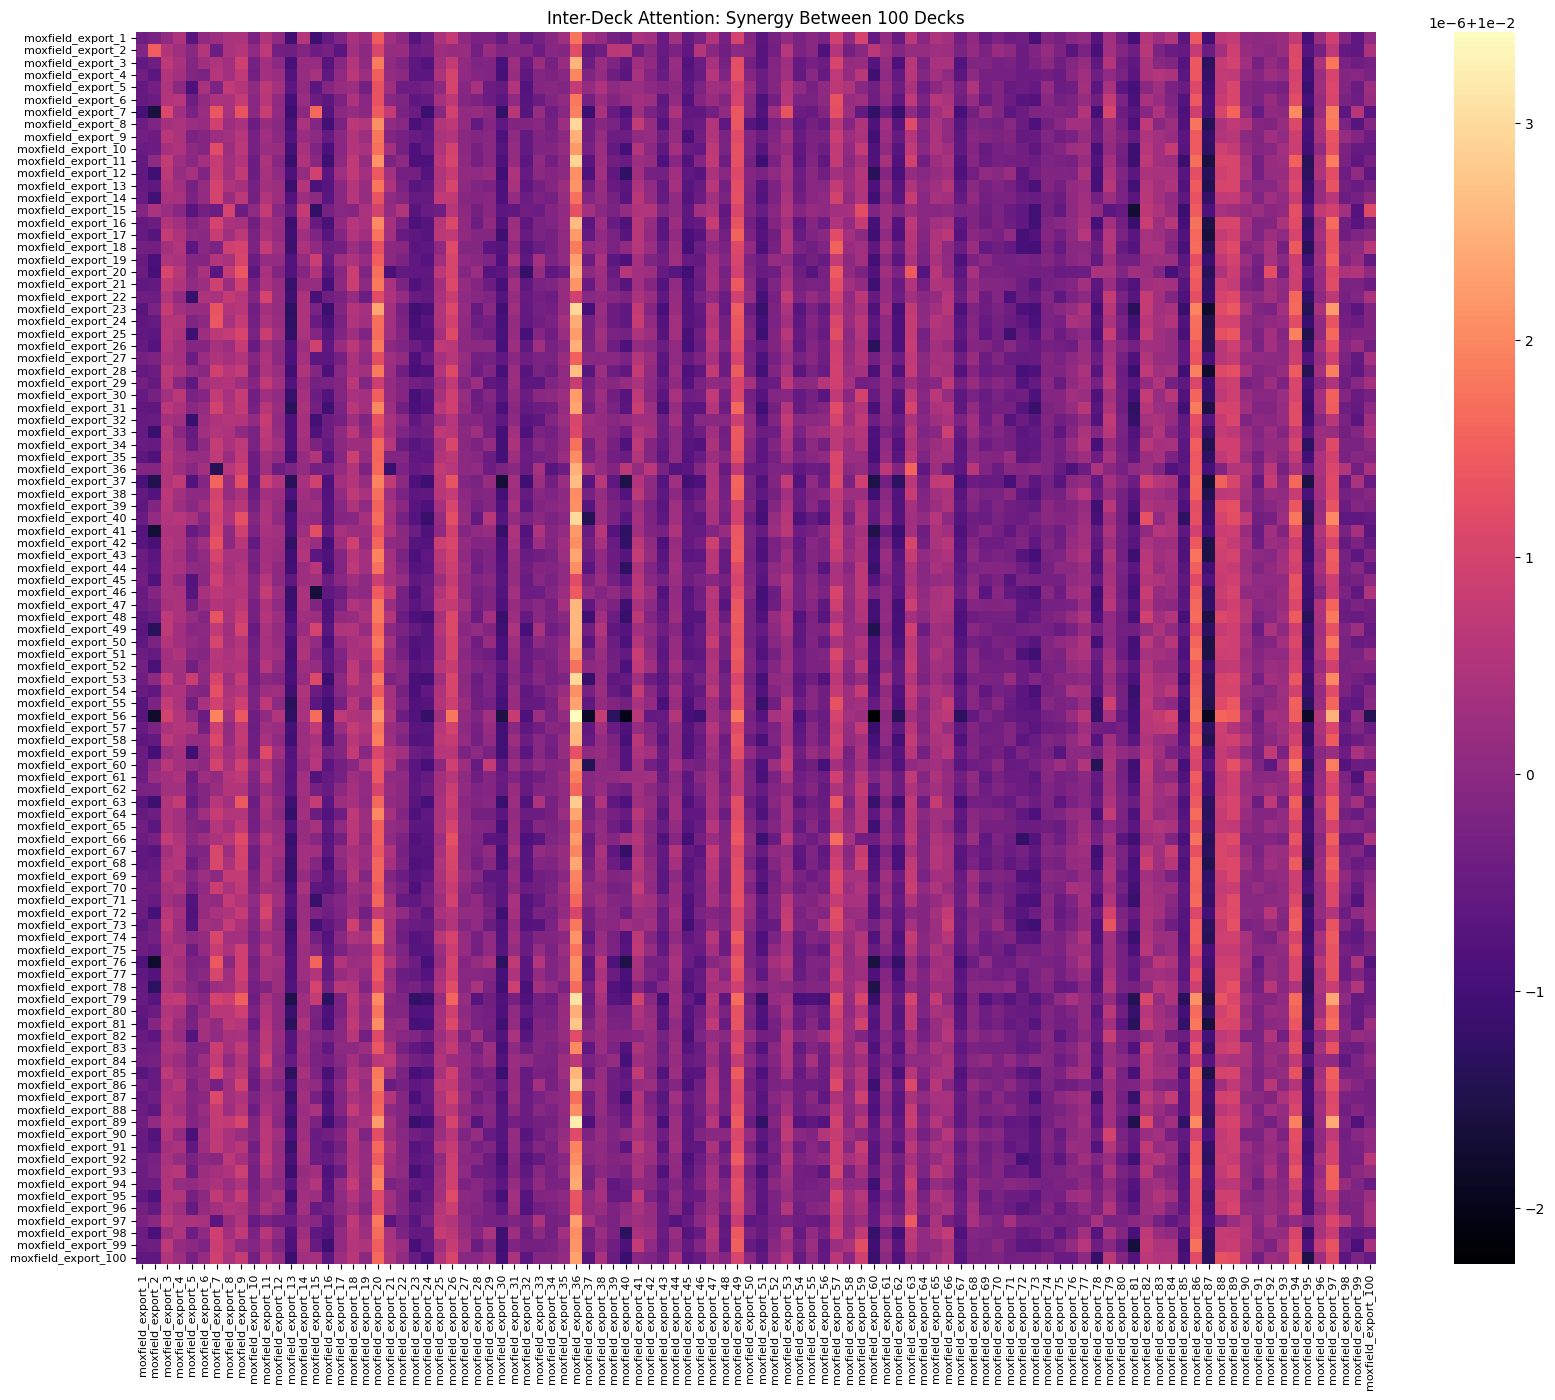

In [ ]:
model = MTGInterDeckAttention(len(tag_to_idx))

# 1. Prepare the data
# Make sure your 'df' is the fattened version with 100 decks
global_tensor = prepare_global_tensor(df, tag_to_idx)

# 2. Extract deck IDs for labeling the heatmap
deck_ids = df['deck_id'].unique()

# 3. Run Inference
weights, latents = model(global_tensor)

# 4. Plot Inter-Deck Synergy
plt.figure(figsize=(20, 16)) # Increased size for 100 labels
sns.heatmap(
    weights[0].detach().numpy(),
    xticklabels=deck_ids,
    yticklabels=deck_ids,
    cmap='magma' # 'magma' or 'viridis' work well for visibility
)

plt.title("Inter-Deck Attention: Synergy Between 100 Decks")
plt.xticks(rotation=90, fontsize=8) # Rotate labels to prevent overlap
plt.yticks(fontsize=8)
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


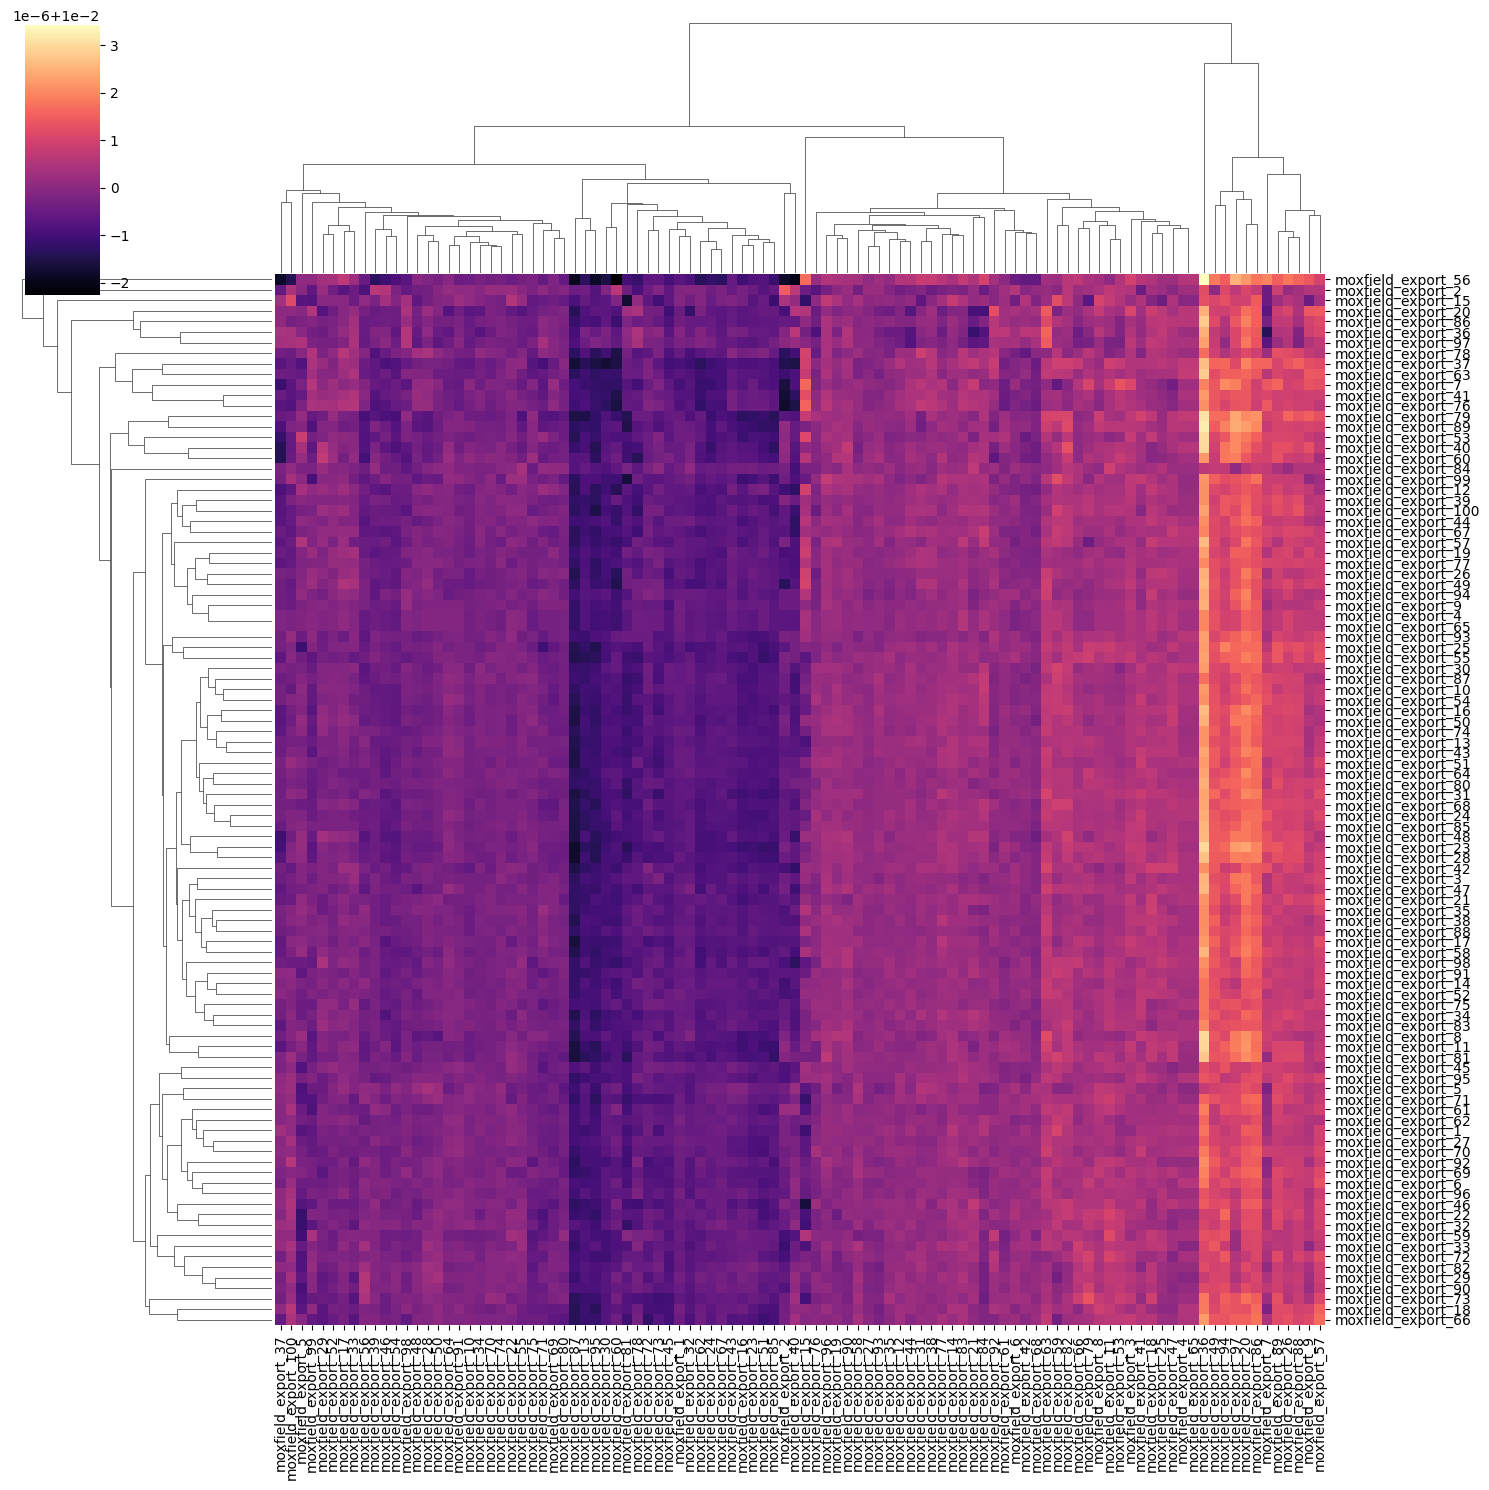

In [ ]:
# Convert weights to a numpy array
attn_matrix = weights[0].detach().numpy()

# Use clustermap to automatically group similar decks
sns.clustermap(
    attn_matrix,
    xticklabels=deck_ids,
    yticklabels=deck_ids,
    cmap='magma',
    figsize=(15, 15)
)
plt.show()

In [ ]:
# !pip install -U sentence-transformers

# Load the Pre-trained Model
# This model 'understands' English mechanics out of the box
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Convert card text to vectors (Embeddings)
df['cleaned_effects'] = df['effects_line'].apply(clean_description)

card_descriptions = (
    df['name'] + " | " +
    df['type_line'] + " | " +
    df['mana_cost'].fillna('') + " | " +
    df['cleaned_effects'] + " | " +
    "Produces: " + df['mana_production'].fillna('Nothing')
).tolist()

# Encode using Sentence Transformer
# This takes the rich description and turns it into a 384-dimensional vector
latent_features = model.encode(card_descriptions, show_progress_bar=True)

# 3. Dimensionality Reduction (T-SNE)
# 2D
tsne_2D = TSNE(n_components=2, perplexity=30, random_state=42)
vis_dims_2D = tsne_2D.fit_transform(latent_features)

# 3D
tsne_3D = TSNE(n_components=3, perplexity=30, random_state=42)
vis_dims_3D = tsne_3D.fit_transform(latent_features)

Batches:   0%|          | 0/314 [00:00<?, ?it/s]

/tmp/ipykernel_8679/2425357221.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(vis_dims_2D[:, 0], vis_dims_2D[:, 1], alpha=0.6, cmap='viridis')


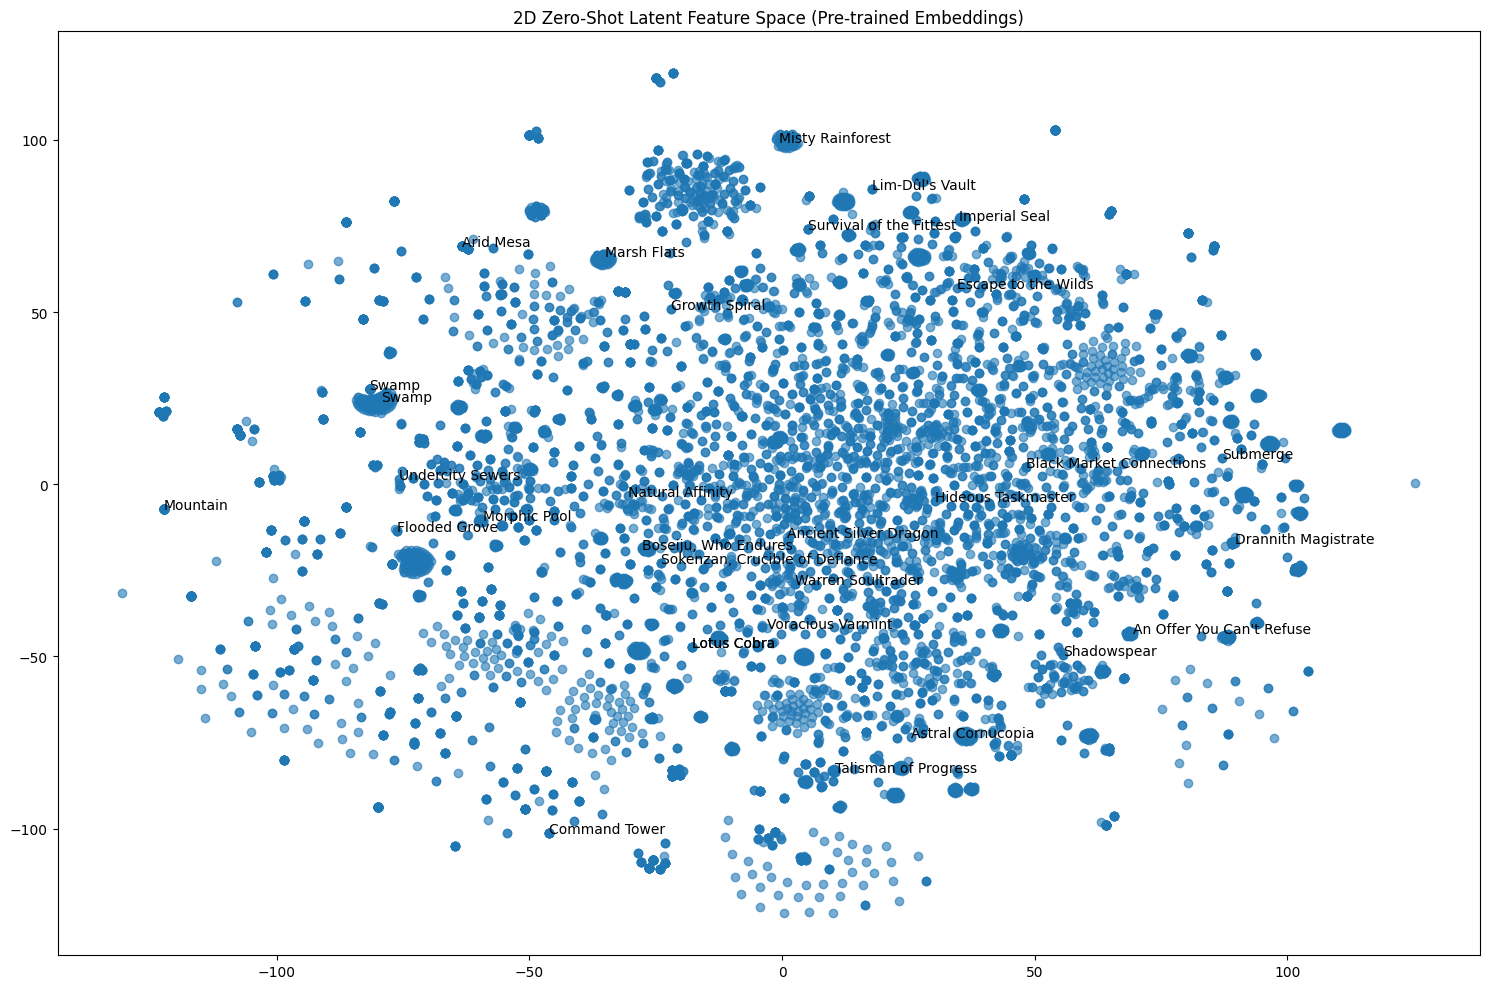

/tmp/ipykernel_8679/2425357221.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(vis_dims_3D[:, 0], vis_dims_3D[:, 1], vis_dims_3D[:, 2],


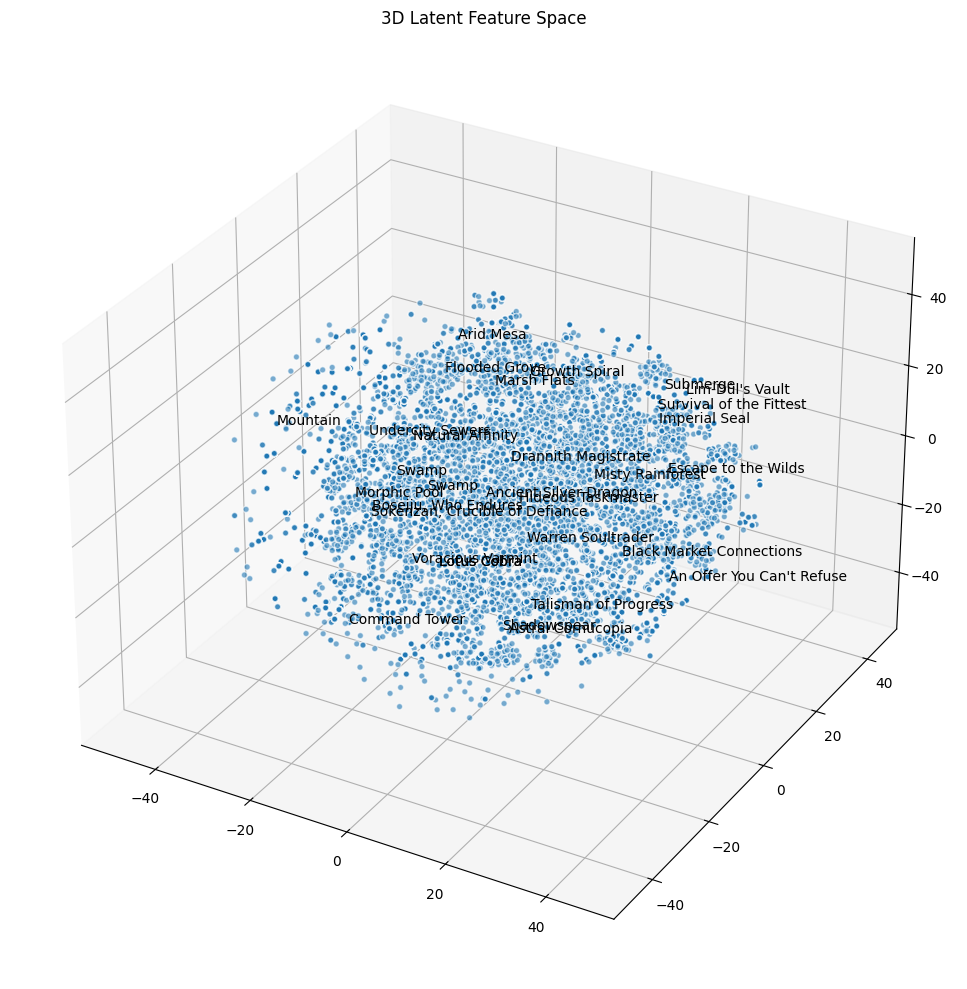

In [ ]:
##### Plotting
### 2D
plt.figure(figsize=(15, 10))
plt.scatter(vis_dims_2D[:, 0], vis_dims_2D[:, 1], alpha=0.6, cmap='viridis')

### Label random cards to verify the clusters
for i in range(0, len(df), len(df)//30):
    plt.annotate(df.iloc[i]['name'], (vis_dims_2D[i, 0], vis_dims_2D[i, 1]), fontsize=10)

plt.title("2D Zero-Shot Latent Feature Space (Pre-trained Embeddings)")
plt.tight_layout()
plt.show()

### 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(vis_dims_3D[:, 0], vis_dims_3D[:, 1], vis_dims_3D[:, 2],
            cmap='viridis', alpha=0.6, edgecolors='w')

# Labeling
for i in range(0, len(df), len(df)//30):
    ax.text(vis_dims_3D[i, 0],
            vis_dims_3D[i, 1],
            vis_dims_3D[i, 2],
            df.iloc[i]['name'],
            fontsize=10)

ax.set_title("3D Latent Feature Space")
plt.tight_layout()
plt.show()

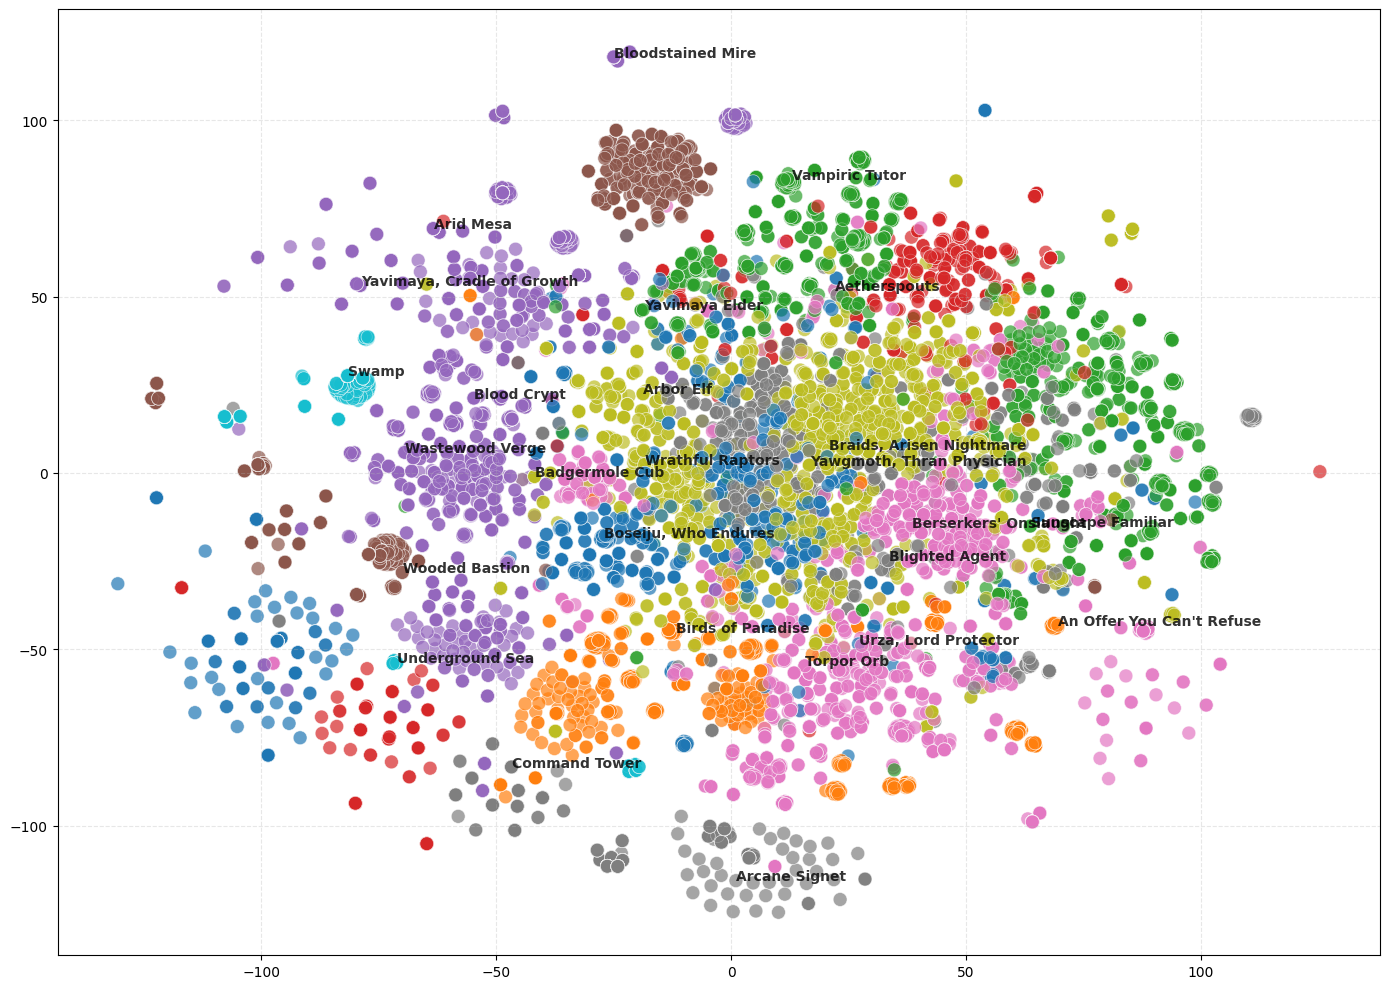

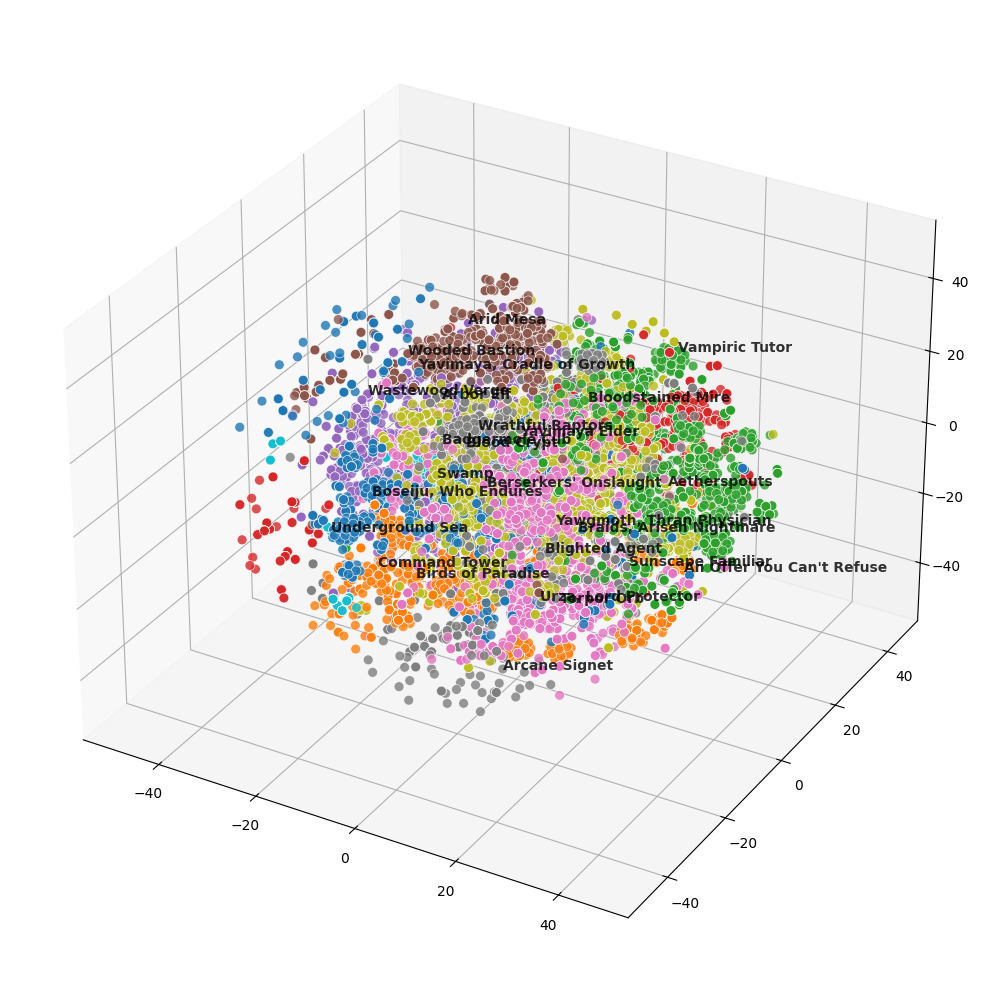

In [ ]:
n_clusters = 20

# The fit
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(latent_features)

# save labels
df['cluster_role'] = cluster_labels

##### Plot 2D with cluster roles
plt.figure(figsize=(14, 10))
scatter_2d = plt.scatter(vis_dims_2D[:, 0],
                         vis_dims_2D[:, 1],
                         c=cluster_labels,
                         cmap='tab10',
                         s=100,
                         alpha=0.7,
                         edgecolors='white',
                         linewidth=0.5)
# Label samples
for i in range(0, len(df), len(df)//25):
    plt.text(vis_dims_2D[i, 0] + 0.1, # Slight offset so text doesn't overlap dot
             vis_dims_2D[i, 1] + 0.1,
             df.iloc[i]['name'],
             fontsize=10,
             fontweight='bold',
             alpha=0.8)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

##### Plot 3D with cluster roles
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(vis_dims_3D[:, 0],
                    vis_dims_3D[:, 1],
                    vis_dims_3D[:, 2],
                    c=cluster_labels,
                    cmap='tab10',
                    s=50,
                    alpha=0.8,
                    edgecolors='white',
                    linewidth=0.5)
# Label samples
for i in range(0, len(df), len(df)//25):
    ax.text(vis_dims_3D[i, 0], vis_dims_3D[i, 1], vis_dims_3D[i, 2],
            df.iloc[i]['name'], fontsize=10, fontweight='bold', alpha=0.8)
plt.tight_layout()
plt.show()

In [ ]:
def visualize_cluster_contents(df, n_clusters, tag_to_idx, idx_to_tag):
    print("=== MTG LATENT ROLE ANALYSIS ===")

    # Data Dictionary Sample for the report
    print("\n[Data Dictionary Sample]")
    sample_tags = list(tag_to_idx.keys())[10:18] # Shifted to see variety
    for t in sample_tags:
        print(f"  Token: '{t}' -> Index: {tag_to_idx[t]}")

    for i in range(n_clusters):
        print(f"\n" + "="*60)
        print(f"🟦 CLUSTER {i}: DISCOVERED ROLE")
        print("="*60)

        # 1. Filter cards in this cluster
        cluster_df = df[df['cluster_role'] == i]

        # 2. Sample Card Names
        sample_names = cluster_df['name'].head(8).tolist()
        print(f"📍 Sample Cards: {', '.join(sample_names)}")

        # 3. Retrace & Aggregate ALL Data Sources
        all_cluster_tokens = []
        for _, row in cluster_df.iterrows():
            # Match the input logic used in your Latent Feature Extraction
            tokens = (
                row['gen_tags'] +
                row['man_tags'] +
                get_tokens(row['effects_line']) +
                get_tokens(row['type_line']) +
                get_tokens(row['mana_cost'], is_mana=True) +
                get_tokens(row['mana_production'], is_mana=True)
            )
            # Only keep tokens that are in our vocabulary
            all_cluster_tokens.extend([t for t in tokens if t in tag_to_idx])

        # Get the top 15 most common descriptors for a richer profile
        common_tokens = Counter(all_cluster_tokens).most_common(15)

        print("\n🔑 Defining Keywords (Retraced):")
        token_str = ""
        # Group them visually for the output
        for token, count in common_tokens:
            if token not in ["EMPTY_DATA", "PAD"]:
                idx = tag_to_idx[token]
                token_str += f"• {token}({idx})  "
        print(token_str)

        # 4. Role Interpretation
        # Filter out generic types to find the actual 'Action'
        meaningful_tokens = [t for t, c in common_tokens if t not in ['creature', 'legendary', 'sorcery', 'instant']]
        top_role = meaningful_tokens[0] if meaningful_tokens else common_tokens[0][0]

        print(f"\n💡 Likely Latent Role: Focuses on '{top_role}' interactions.")

In [ ]:
# Run the visualization
visualize_cluster_contents(df, n_clusters, tag_to_idx, idx_to_tag)

=== MTG LATENT ROLE ANALYSIS ===

[Data Dictionary Sample]
  Token: 'Aether Reservoir' -> Index: 11
  Token: 'Aether Spellbomb' -> Index: 12
  Token: 'Affinity' -> Index: 13
  Token: 'Aggression' -> Index: 14
  Token: 'Aggressive' -> Index: 15
  Token: 'Aggressive Aggro' -> Index: 16
  Token: 'Aggressive Ape' -> Index: 17
  Token: 'Aggressive Archetype' -> Index: 18

🟦 CLUSTER 0: DISCOVERED ROLE
📍 Sample Cards: Mountain, Mountain, Mountain, Mountain, Mountain, Mountain, Mountain, Graven Cairns

🔑 Defining Keywords (Retraced):
• tap-ability(2525)  • land(2162)  • {r}(2710)  • mountain(2254)  • basic(1735)  • Ramp(1170)  • Blood Rush(143)  • Gathering Deck(639)  • Mana Ramp(989)  • snow(2477)  • Plateau(1142)  • Tap-and-Boost(1427)  • plains(2344)  • {w}(2718)  • Graveyard(714)  

💡 Likely Latent Role: Focuses on 'tap-ability' interactions.

🟦 CLUSTER 1: DISCOVERED ROLE
📍 Sample Cards: Gemstone Caverns, Minamo, School at Water's Edge, Otawara, Soaring City, Ragavan, Nimble Pilferer, Simi

In [ ]:
# 1. We take the latents from the model inference earlier
# latents shape: [1, 100, 16] -> convert to [100, 16]
deck_features = latents[0].detach().numpy()

# 2. Fit K-Means for your 5 observed clusters
n_deck_clusters = 5
deck_kmeans = KMeans(n_clusters=n_deck_clusters, n_init=10, random_state=42)
deck_cluster_labels = deck_kmeans.fit_predict(deck_features)

# 3. Create a mapping DataFrame
deck_archetypes = pd.DataFrame({
    'deck_id': deck_ids,
    'archetype_cluster': deck_cluster_labels
})

In [ ]:
# --- 2D REDUCTION ---
reducer_2d = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)
deck_2d = reducer_2d.fit_transform(deck_features)

deck_archetypes['x2'] = deck_2d[:, 0]
deck_archetypes['y2'] = deck_2d[:, 1]

fig_2d = px.scatter(deck_archetypes, x='x2', y='y2',
                    color='archetype_cluster',
                    hover_name='deck_id',
                    template='plotly_dark',
                    title="2D Deck Archetype Projection (UMAP)")
fig_2d.show()

# --- 3D REDUCTION ---
reducer_3d = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=3, random_state=42)
deck_3d = reducer_3d.fit_transform(deck_features)

deck_archetypes['x3'] = deck_3d[:, 0]
deck_archetypes['y3'] = deck_3d[:, 1]
deck_archetypes['z3'] = deck_3d[:, 2]

fig_3d = px.scatter_3d(deck_archetypes, x='x3', y='y3', z='z3',
                       color='archetype_cluster',
                       hover_name='deck_id',
                       opacity=0.8,
                       template='plotly_dark',
                       title="3D Deck Archetype Space")

# Adjust marker size for better visibility in 3D
fig_3d.update_traces(marker=dict(size=5))
fig_3d.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [ ]:
def analyze_deck_archetypes_with_tags(df, deck_archetypes, tag_to_idx):
    # 1. Merge labels so every card knows its deck's archetype
    full_df = df.merge(deck_archetypes, on='deck_id')

    print("=== GLOBAL ARCHETYPE MECHANICAL ANALYSIS ===")

    for i in sorted(full_df['archetype_cluster'].unique()):
        print(f"\n" + "="*60)
        print(f"🏰 ARCHETYPE CLUSTER {i}")
        print("="*60)

        cluster_df = full_df[full_df['archetype_cluster'] == i]

        # 2. Identify the "Signature Decks"
        unique_decks = cluster_df['deck_id'].unique()
        print(f"📊 Representation: {len(unique_decks)} decks")
        print(f"📍 Sample Decks: {', '.join(unique_decks[:3])}")

        # 3. Retrace Tags across the entire cluster
        all_archetype_tokens = []
        for _, row in cluster_df.iterrows():
            # Combine all mechanical sources
            tokens = (
                row['gen_tags'] +
                row['man_tags'] +
                get_tokens(row['effects_line']) +
                get_tokens(row['type_line'])
            )
            # Filter against your master vocabulary
            all_archetype_tokens.extend([t for t in tokens if t in tag_to_idx])

        # 4. Get Top 15 Signature Keywords for the Archetype
        # We filter out very generic tags (creature, land) to see the "flavor"
        generic_filters = {'creature', 'land', 'legendary', 'the', 'you', 'EMPTY_DATA'}
        sig_keywords = [
            (t, c) for t, c in Counter(all_archetype_tokens).most_common(50)
            if t not in generic_filters
        ][:15]

        print("\n🔑 Archetype Signature Tags:")
        tag_line = ""
        for tag, count in sig_keywords:
            tag_line += f"• {tag} "
        print(tag_line)

        # 5. Dominant Card Roles
        # This connects your card-level K-Means to your deck-level clusters
        top_roles = cluster_df['cluster_role'].value_counts(normalize=True).head(3)
        print(f"\n🎭 Core Card Roles: {top_roles.index.tolist()}")

        print(f"\n💡 Summary: This archetype is defined by {sig_keywords[0][0]} and {sig_keywords[1][0]} strategies.")

In [ ]:
analyze_deck_archetypes_with_tags(df, deck_archetypes, tag_to_idx)

=== GLOBAL ARCHETYPE MECHANICAL ANALYSIS ===

🏰 ARCHETYPE CLUSTER 0
📊 Representation: 7 decks
📍 Sample Decks: moxfield_export_15, moxfield_export_20, moxfield_export_26

🔑 Archetype Signature Tags:
• tap-ability • artifact • control • sacrifice • graveyard • mana • may • enters • token • for • basic • turn • put • damage • one 

🎭 Core Card Roles: [12, 0, 17]

💡 Summary: This archetype is defined by tap-ability and artifact strategies.

🏰 ARCHETYPE CLUSTER 1
📊 Representation: 41 decks
📍 Sample Decks: moxfield_export_1, moxfield_export_3, moxfield_export_4

🔑 Archetype Signature Tags:
• tap-ability • control • sacrifice • artifact • shuffle • put • may • for • mana • spell • library • enters • cast • life • one 

🎭 Core Card Roles: [8, 17, 4]

💡 Summary: This archetype is defined by tap-ability and control strategies.

🏰 ARCHETYPE CLUSTER 2
📊 Representation: 15 decks
📍 Sample Decks: moxfield_export_2, moxfield_export_5, moxfield_export_22

🔑 Archetype Signature Tags:
• tap-ability • con

In [ ]:
# 1. Take the 16D latents from the Inter-Deck model
deck_features = latents[0].detach().numpy()

# 2. Project into 2D
# Note: Perplexity ~15 is good for 100 points
tsne_2d = TSNE(n_components=2, perplexity=15, random_state=42)
deck_2d_coords = tsne_2d.fit_transform(deck_features)

# 3. Add to your existing archetype dataframe
deck_archetypes['tsne_x'] = deck_2d_coords[:, 0]
deck_archetypes['tsne_y'] = deck_2d_coords[:, 1]
deck_archetypes['cluster_label'] = deck_archetypes['archetype_cluster'].apply(lambda x: f"Archetype {x}")

# 4. Interactive Plot
fig_tsne_2d = px.scatter(
    deck_archetypes,
    x='tsne_x', y='tsne_y',
    color='cluster_label',
    hover_name='deck_id',
    template='plotly_dark',
    title="2D Deck Archetype Landscape (t-SNE)",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_tsne_2d.update_traces(marker=dict(size=12, line=dict(width=1, color='white')))
fig_tsne_2d.show()

# 1. Project into 3D
tsne_3d = TSNE(n_components=3, perplexity=15, random_state=42)
deck_3d_coords = tsne_3d.fit_transform(deck_features)

# 2. Add coordinates
deck_archetypes['tsne_x3'] = deck_3d_coords[:, 0]
deck_archetypes['tsne_y3'] = deck_3d_coords[:, 1]
deck_archetypes['tsne_z3'] = deck_3d_coords[:, 2]

# 3. Interactive Plot
fig_tsne_3d = px.scatter_3d(
    deck_archetypes,
    x='tsne_x3', y='tsne_y3', z='tsne_z3',
    color='cluster_label',
    hover_name='deck_id',
    template='plotly_dark',
    title="3D Deck Archetype Galaxy (t-SNE)",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_tsne_3d.update_traces(marker=dict(size=6, opacity=0.8))
fig_tsne_3d.show()

K-means clustering --> Archetype --> type of deck
This algorithm hard assigns every deck into an archetype (pick a leader [centroid]).
- Goal: to minimize the distance between data points and their assigned center
- Result: Rigid and harsh. If ratio is 51% to 49% it will hard assign to 51%
- Shape: Circular/Spherical groups
- Use: Identification. Centroid

t-SNE --> Dimensionality Reduction --> synergy (Everything is relative)
This algorithm does not know what a "cluster" is, knows about neighborhoods.
- Goal: To reduce dimensionality, keeping close neighbors close and distant enemies far.
- Result: Shows a landscape, and compares the ratio/shape similarity in general.
- Shape: Tendrils/Islands/Strings
- Use: Comparison of similarity and general ration/shape. Local Density

"Are these decks close together because they are the same archetype (K-Means), or are they different archetypes that happen to share a specific synergy (t-SNE)?"